# **Problem Statment**

Farmers often face difficulty in determining whether irrigation is required at a particular time. Improper irrigation decisions can lead to water wastage, increased costs, and reduced crop productivity.

The objective of this model is to predict whether irrigation is required based on environmental, soil, and crop-related parameters such as temperature, rainfall, soil moisture, humidity, and crop growth stage.

# **Import Libraries**

In [3]:
import pandas as pd
import numpy as np

# **Load Dataset**

In [4]:
df =pd.read_csv('D:\Machine Learning\Smart-Irrigation-Project\Data\processed\smart_irrigation_cleaned.csv')
df.head()

,growth_stage,temperature,humidity,rainfall,forecast_rainfall,wind_speed,solar_radiation,pressure,cloud_cover,dew_point,...,crop_type_Sugarcane,crop_type_Wheat,region_North,region_South,region_West,soil_type_Loamy,soil_type_Sandy,soil_type_Silty,irrigation_type_Flood,irrigation_type_Sprinkler
0,3,30.11,56.83,244.37,25.49,16.22,494.42,956.28,18.19,7.38,...,0,0,0,0,0,1,0,0,0,0
1,2,16.98,33.83,77.67,7.17,14.98,958.41,971.66,49.19,28.17,...,0,0,0,0,1,0,0,1,0,1
2,2,41.51,56.24,241.26,38.82,4.25,944.36,1022.92,2.19,16.81,...,1,0,1,0,0,0,0,0,0,1
3,3,37.59,34.14,124.00,73.21,3.65,712.11,976.40,35.25,23.10,...,0,0,0,0,0,0,0,0,0,0
4,2,26.36,72.79,79.94,21.39,3.91,995.69,970.73,5.53,22.34,...,0,0,0,0,0,0,1,0,0,0


# **Check Dataset Shape**

In [5]:
df.shape

(10000, 48)

# **Check Column Names**

In [6]:
df.columns

Index(['growth_stage', 'temperature', 'humidity', 'rainfall',
       'forecast_rainfall', 'wind_speed', 'solar_radiation', 'pressure',
       'cloud_cover', 'dew_point', 'soil_moisture', 'soil_temperature',
       'soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'organic_matter',
       'ec', 'leaf_wetness', 'evapotranspiration', 'ndvi', 'crop_age_days',
       'water_usage', 'pest_risk', 'disease_risk', 'crop_health_index',
       'previous_yield', 'groundwater_level', 'reservoir_level',
       'fertilizer_usage', 'labor_hours', 'water_quantity_required_liters',
       'future_soil_moisture_3day', 'crop_water_stress_level',
       'irrigation_required', 'yield_prediction', 'crop_type_Maize',
       'crop_type_Rice', 'crop_type_Sugarcane', 'crop_type_Wheat',
       'region_North', 'region_South', 'region_West', 'soil_type_Loamy',
       'soil_type_Sandy', 'soil_type_Silty', 'irrigation_type_Flood',
       'irrigation_type_Sprinkler'],
      dtype='object')

# **Check Data Types & Null Values**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   growth_stage                    10000 non-null  int64  
 1   temperature                     10000 non-null  float64
 2   humidity                        10000 non-null  float64
 3   rainfall                        10000 non-null  float64
 4   forecast_rainfall               10000 non-null  float64
 5   wind_speed                      10000 non-null  float64
 6   solar_radiation                 10000 non-null  float64
 7   pressure                        10000 non-null  float64
 8   cloud_cover                     10000 non-null  float64
 9   dew_point                       10000 non-null  float64
 10  soil_moisture                   10000 non-null  float64
 11  soil_temperature                10000 non-null  float64
 12  soil_ph                         1

# **Define Features & Target**

In [8]:
X = df.drop(
    columns=[
        'irrigation_required',
        'water_quantity_required_liters',
        'future_soil_moisture_3day',
        'yield_prediction'
    ]
)

y = df['irrigation_required']



In [9]:
X

,growth_stage,temperature,humidity,rainfall,forecast_rainfall,wind_speed,solar_radiation,pressure,cloud_cover,dew_point,...,crop_type_Sugarcane,crop_type_Wheat,region_North,region_South,region_West,soil_type_Loamy,soil_type_Sandy,soil_type_Silty,irrigation_type_Flood,irrigation_type_Sprinkler
0,3,30.11,56.83,244.37,25.49,16.22,494.42,956.28,18.19,7.38,...,0,0,0,0,0,1,0,0,0,0
1,2,16.98,33.83,77.67,7.17,14.98,958.41,971.66,49.19,28.17,...,0,0,0,0,1,0,0,1,0,1
2,2,41.51,56.24,241.26,38.82,4.25,944.36,1022.92,2.19,16.81,...,1,0,1,0,0,0,0,0,0,1
3,3,37.59,34.14,124.00,73.21,3.65,712.11,976.40,35.25,23.10,...,0,0,0,0,0,0,0,0,0,0
4,2,26.36,72.79,79.94,21.39,3.91,995.69,970.73,5.53,22.34,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3,26.20,59.10,56.35,79.90,4.79,889.47,1033.28,60.84,24.43,...,1,0,0,0,1,0,1,0,1,0
9996,0,43.02,72.26,122.98,15.10,25.83,835.13,1019.34,55.47,17.20,...,1,0,0,0,0,0,0,1,0,0
9997,1,43.68,37.26,202.85,46.27,12.22,623.76,998.58,51.32,20.68,...,0,1,0,1,0,0,0,0,1,0
9998,3,32.46,76.37,89.30,30.46,18.61,698.84,962.22,24.64,1.85,...,0,1,0,1,0,0,1,0,0,1


# **Train_Test_Split**

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)


In [11]:
X_train.shape

(8000, 44)

In [12]:
X_test.shape

(2000, 44)

In [13]:
y_train.shape

(8000,)

In [14]:
y_test.shape

(2000,)

# **Check Class Balance**

In [15]:
df['irrigation_required'].value_counts(normalize=True) *100

irrigation_required
0    89.55
1    10.45
Name: proportion, dtype: float64

# **Apply SMOTE on Training Data**

In [16]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
x_train_balanced,y_train_balanced = sm.fit_resample(X_train,y_train)



In [17]:
y_train_balanced.value_counts()

irrigation_required
0    7180
1    7180
Name: count, dtype: int64

# **Model Building**

# **1.Logistic Regression**

In [18]:
from sklearn.linear_model import LogisticRegression

# Train model

In [19]:
logistic = LogisticRegression()
logistic.fit(x_train_balanced,y_train_balanced)

c:\Users\Sourabh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
#check traing and testing accuracy
train_prediction =logistic.predict(X_train)
test_prediction = logistic.predict(X_test)

In [21]:
y_probab = logistic.predict_proba(X_test)[:,1]

In [22]:
from sklearn.metrics import accuracy_score,classification_report,f1_score,precision_score,recall_score,confusion_matrix,roc_auc_score,roc_curve

# Accuracy Check

In [23]:
train_accuracy = accuracy_score(y_train,train_prediction)
test_accuracy = accuracy_score(y_test,test_prediction)

print("Training Accuracy Is:",round(train_accuracy*100,2))
print("Testing Accuracy Is:",round(test_accuracy*100,2))

Training Accuracy Is: 95.01
Testing Accuracy Is: 95.05


In [24]:
# check accuracy gap between taring and testing accuracy
Accuracy_gap = abs(train_accuracy - test_accuracy)

print("Accuracy Gap Is:",round(Accuracy_gap*100,2))

Accuracy Gap Is: 0.04


# Classification Metrices

In [25]:
print("Classification Report Is:\n",classification_report(y_test,test_prediction))
print("F1 Score Is:",round(f1_score(y_test,test_prediction),4))
print("Precision Score Is:",round(precision_score(y_test,test_prediction),4))
print("Recall Score Is:",round(recall_score(y_test,test_prediction),4))
cm=confusion_matrix(y_test,test_prediction)
print("Confusion Matrix Is:\n",cm)


Classification Report Is:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97      1775
           1       0.72      0.93      0.81       225

    accuracy                           0.95      2000
   macro avg       0.85      0.94      0.89      2000
weighted avg       0.96      0.95      0.95      2000

F1 Score Is: 0.8085
Precision Score Is: 0.7158
Recall Score Is: 0.9289
Confusion Matrix Is:
 [[1692   83]
 [  16  209]]


# **Confusion Matrix Heatmap**

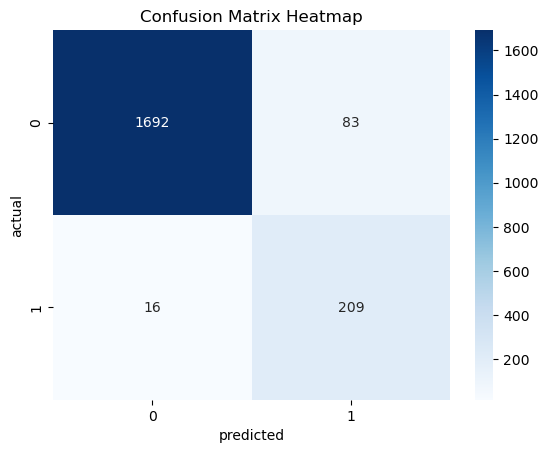

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

ROC-AUC Score: 0.9894


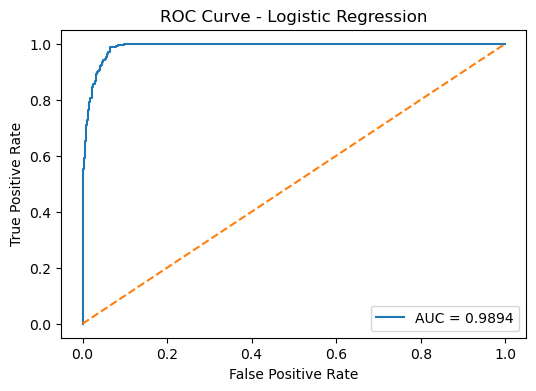

In [27]:
# Probability predictions
y_prob = logistic.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc_score, 4))

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# Using Hyper Parameter Tuning

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'penalty': ['l1','l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear','saga'],
    'class_weight': [None, 'balanced'],
    'max_iter' : [500,1000]
}

In [29]:
logistic_tuning = LogisticRegression()
grid_search = GridSearchCV(
    estimator=logistic_tuning,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [30]:
grid_search.fit(x_train_balanced,y_train_balanced)


best_lr = grid_search.best_estimator_

print(grid_search.best_params_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


{'C': 0.1, 'class_weight': None, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}


In [31]:

train_prediction_tune = best_lr.predict(X_train)
test_prediction_tune = best_lr.predict(X_test)

# **Checking Accuracy**

In [32]:
train_accuracy_lr = accuracy_score(y_train,train_prediction_tune)
test_accuracy_lr = accuracy_score(y_test,test_prediction_tune)

print("Training Accuracy Is:",round(train_accuracy_lr*100,2))
print("Testing Accuracy Is:",round(test_accuracy_lr*100,2))

Training Accuracy Is: 96.26
Testing Accuracy Is: 96.2


In [33]:
Accuracy_gap_Tune = train_accuracy_lr - test_accuracy_lr

print("Accuracy Gap For Tuning Is:",round(Accuracy_gap_Tune*100,2))

Accuracy Gap For Tuning Is: 0.06


In [34]:
print(grid_search.best_score_)

0.9709920378323691


In [35]:
y_pred_tune =best_lr.predict(X_test)

In [36]:
print(classification_report(y_test,y_pred_tune))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1775
           1       0.80      0.88      0.84       225

    accuracy                           0.96      2000
   macro avg       0.89      0.93      0.91      2000
weighted avg       0.96      0.96      0.96      2000



In [37]:
f1_score_lr = round(f1_score(y_test, y_pred_tune), 4)
precision_score_lr = round(precision_score(y_test, y_pred_tune), 4)
recall_lr = round(recall_score(y_test, y_pred_tune), 4)

In [38]:
print("Classification Report Is:\n",classification_report(y_test,y_pred_tune))
print("F1 Score Is:",round(f1_score(y_test,y_pred_tune),4))
print("Precision Score Is:",round(precision_score(y_test,y_pred_tune),4))
print("Recall Score Is:",round(recall_score(y_test,y_pred_tune),4))
cm=confusion_matrix(y_test,y_pred_tune)
print("Confusion Matrix Is:\n",cm)

Classification Report Is:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98      1775
           1       0.80      0.88      0.84       225

    accuracy                           0.96      2000
   macro avg       0.89      0.93      0.91      2000
weighted avg       0.96      0.96      0.96      2000

F1 Score Is: 0.839
Precision Score Is: 0.8016
Recall Score Is: 0.88
Confusion Matrix Is:
 [[1726   49]
 [  27  198]]


ROC-AUC Score: 0.9895


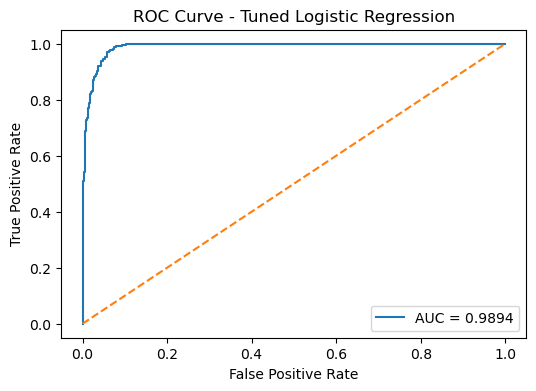

In [39]:
# Probability predictions
y_prob = best_lr.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score_lr = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc_score_lr, 4))

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend()
plt.show()

# **Compariosn**

In [40]:
comparison = pd.DataFrame({
    'Model' : [
        'Default LR',
        'Tuned LR'
    ],
    'Train Accuracy': [
        accuracy_score(y_train,train_prediction),
        accuracy_score(y_train,train_prediction_tune)

    ],
    'Test Accuracy' : [
        accuracy_score(y_test,test_prediction),
        accuracy_score(y_test,test_prediction_tune)
        
    ],
    'Precision'  : [
        precision_score(y_test,test_prediction),
        precision_score(y_test,y_pred_tune)
    ],
    'Recall' : [
        recall_score(y_test,test_prediction),
        recall_score(y_test,y_pred_tune)
    ],
    'F1' : [
        f1_score(y_test,test_prediction),
        f1_score(y_test,y_pred_tune)
        
    ]
    
})

comparison.iloc[:,1:] = comparison.iloc[:,1:].round(3)


In [41]:
comparison

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1
0,Default LR,0.950,0.950,0.716,0.929,0.809
1,Tuned LR,0.963,0.962,0.802,0.880,0.839


# **2.Decision Tree**

## Load Dataset

In [42]:
df = pd.read_csv('D:\Machine Learning\Smart-Irrigation-Project\Data\processed\smart_irrigation_cleaned.csv')
df.head()

,growth_stage,temperature,humidity,rainfall,forecast_rainfall,wind_speed,solar_radiation,pressure,cloud_cover,dew_point,...,crop_type_Sugarcane,crop_type_Wheat,region_North,region_South,region_West,soil_type_Loamy,soil_type_Sandy,soil_type_Silty,irrigation_type_Flood,irrigation_type_Sprinkler
0,3,30.11,56.83,244.37,25.49,16.22,494.42,956.28,18.19,7.38,...,0,0,0,0,0,1,0,0,0,0
1,2,16.98,33.83,77.67,7.17,14.98,958.41,971.66,49.19,28.17,...,0,0,0,0,1,0,0,1,0,1
2,2,41.51,56.24,241.26,38.82,4.25,944.36,1022.92,2.19,16.81,...,1,0,1,0,0,0,0,0,0,1
3,3,37.59,34.14,124.00,73.21,3.65,712.11,976.40,35.25,23.10,...,0,0,0,0,0,0,0,0,0,0
4,2,26.36,72.79,79.94,21.39,3.91,995.69,970.73,5.53,22.34,...,0,0,0,0,0,0,1,0,0,0


In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
decision_treee = DecisionTreeClassifier()
decision_treee.fit(x_train_balanced,y_train_balanced)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
training_prediction = decision_treee.predict(X_train)
testing_prediction = decision_treee.predict(X_test)

In [46]:
y_probab_decision = decision_treee.predict_proba(X_test)[:,1]

# **Accuracy Check**

In [47]:
training_accuracy = accuracy_score(y_train,training_prediction)
testing_accuracy = accuracy_score(y_test,testing_prediction)

print("Traing Accuracy Is:",round(training_accuracy*100,2))
print("Testing Accuracy Is:",round(testing_accuracy*100,2))


Traing Accuracy Is: 100.0
Testing Accuracy Is: 99.8


In [48]:
Accuracy_gap_decision = training_accuracy - testing_accuracy

print("Accuracy Gap Is:",round(Accuracy_gap_decision*100,2))

Accuracy Gap Is: 0.2


In [49]:
print("                     Classification Report \n",classification_report(y_test,testing_prediction))
print("F1 Score Is:",round(f1_score(y_test,testing_prediction),4))
print("Precision Score Is:",round(precision_score(y_test,testing_prediction),4))
print("Recall Score Is:",round(recall_score(y_test,testing_prediction),4))
cm_decision = confusion_matrix(y_test,y_probab_decision)

                     Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1775
           1       1.00      0.99      0.99       225

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

F1 Score Is: 0.9911
Precision Score Is: 0.9955
Recall Score Is: 0.9867


# Confusion Matrix Heatmap for Decision Tree

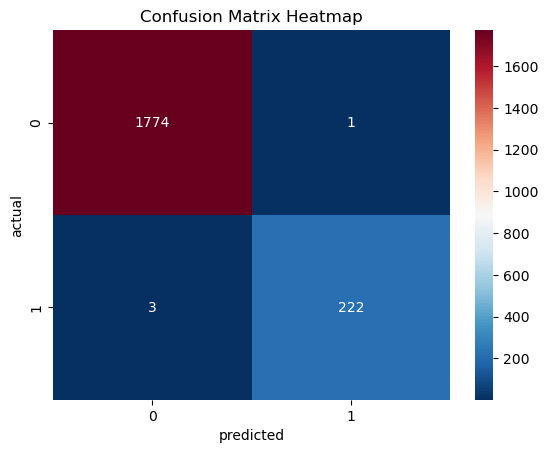

In [50]:
sns.heatmap(cm_decision,annot=True,fmt='d',cmap='RdBu_r')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

# **ROC Curve For Decision Tree**

ROC-AUC Score: 0.9931


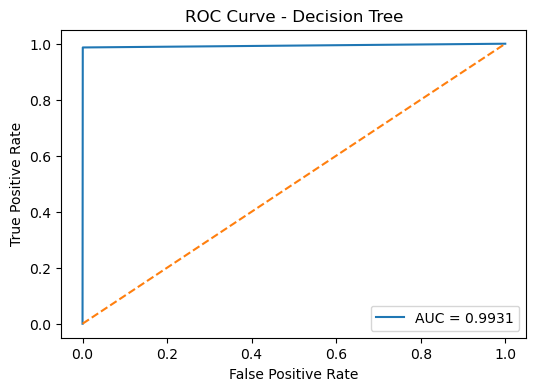

In [51]:
# Probability predictions
y_probab_decision = decision_treee.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_probab_decision)

# AUC Score
auc_score = roc_auc_score(y_test, y_probab_decision)

print("ROC-AUC Score:", round(auc_score, 4))

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

# **Decision Tree Hyper Parameter Tuning**

In [52]:
param_grid={
    'criterion' : ['gini','entropy'],
    'max_depth' : [10,20],
    'min_samples_split' : [5,7,10],
    'min_samples_leaf' : [2,4],
    'max_features': ['sqrt', 'log2', None]
}

In [53]:
dt = DecisionTreeClassifier(random_state=42)

In [54]:
grid_search_dt= GridSearchCV(
    estimator = dt,
    param_grid = param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [55]:
grid_search_dt.fit(x_train_balanced,y_train_balanced)



print("Best Parameters:",grid_search_dt.best_params_)

print("\nBest CV F1 Score:")
print(round(grid_search_dt.best_score_, 4))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best CV F1 Score:
0.9995


In [56]:
best_decision = grid_search_dt.best_estimator_

In [57]:
training_prediction_dt = best_decision.predict(X_train)
testing_prediction_dt = best_decision.predict(X_test)

In [58]:
y_probab_decision_tune = best_decision.predict_proba(X_test)[:,1]

# **Checking Accuracy**

In [59]:
training_accuracy_dt = accuracy_score(y_train,training_prediction_dt)
testing_accuracy_dt = accuracy_score(y_test,testing_prediction_dt)


print("Training Accuracy Is:",round(training_accuracy_dt*100,2))
print("Testing Accuracy IS:",round(testing_accuracy_dt*100,2))

Training Accuracy Is: 100.0
Testing Accuracy IS: 99.9


In [60]:
Accuracy_gap_dt = training_accuracy_dt - testing_accuracy_dt

print("Accuracy Gap Is:", round(Accuracy_gap_dt*100,2))

Accuracy Gap Is: 0.1


In [61]:
y_pred_dt = best_decision.predict(X_test)

In [62]:
f1_score_dt = round(f1_score(y_test, testing_prediction_dt), 4)
precision_score_dt = round(precision_score(y_test, testing_prediction_dt), 4)
recall_dt = round(recall_score(y_test, testing_prediction_dt), 4)

In [63]:
print("                     Classification Report \n",classification_report(y_test,testing_prediction_dt))
print("F1 Score Is:",round(f1_score(y_test,testing_prediction_dt),4))
print("Precision Score Is:",round(precision_score(y_test,testing_prediction_dt),4))
print("Recall Score Is:",round(recall_score(y_test,testing_prediction_dt),4))
cm_decision = confusion_matrix(y_test,testing_prediction_dt)

                     Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1775
           1       1.00      1.00      1.00       225

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

F1 Score Is: 0.9956
Precision Score Is: 0.9956
Recall Score Is: 0.9956


# **Plot Tuned Decision Tree**

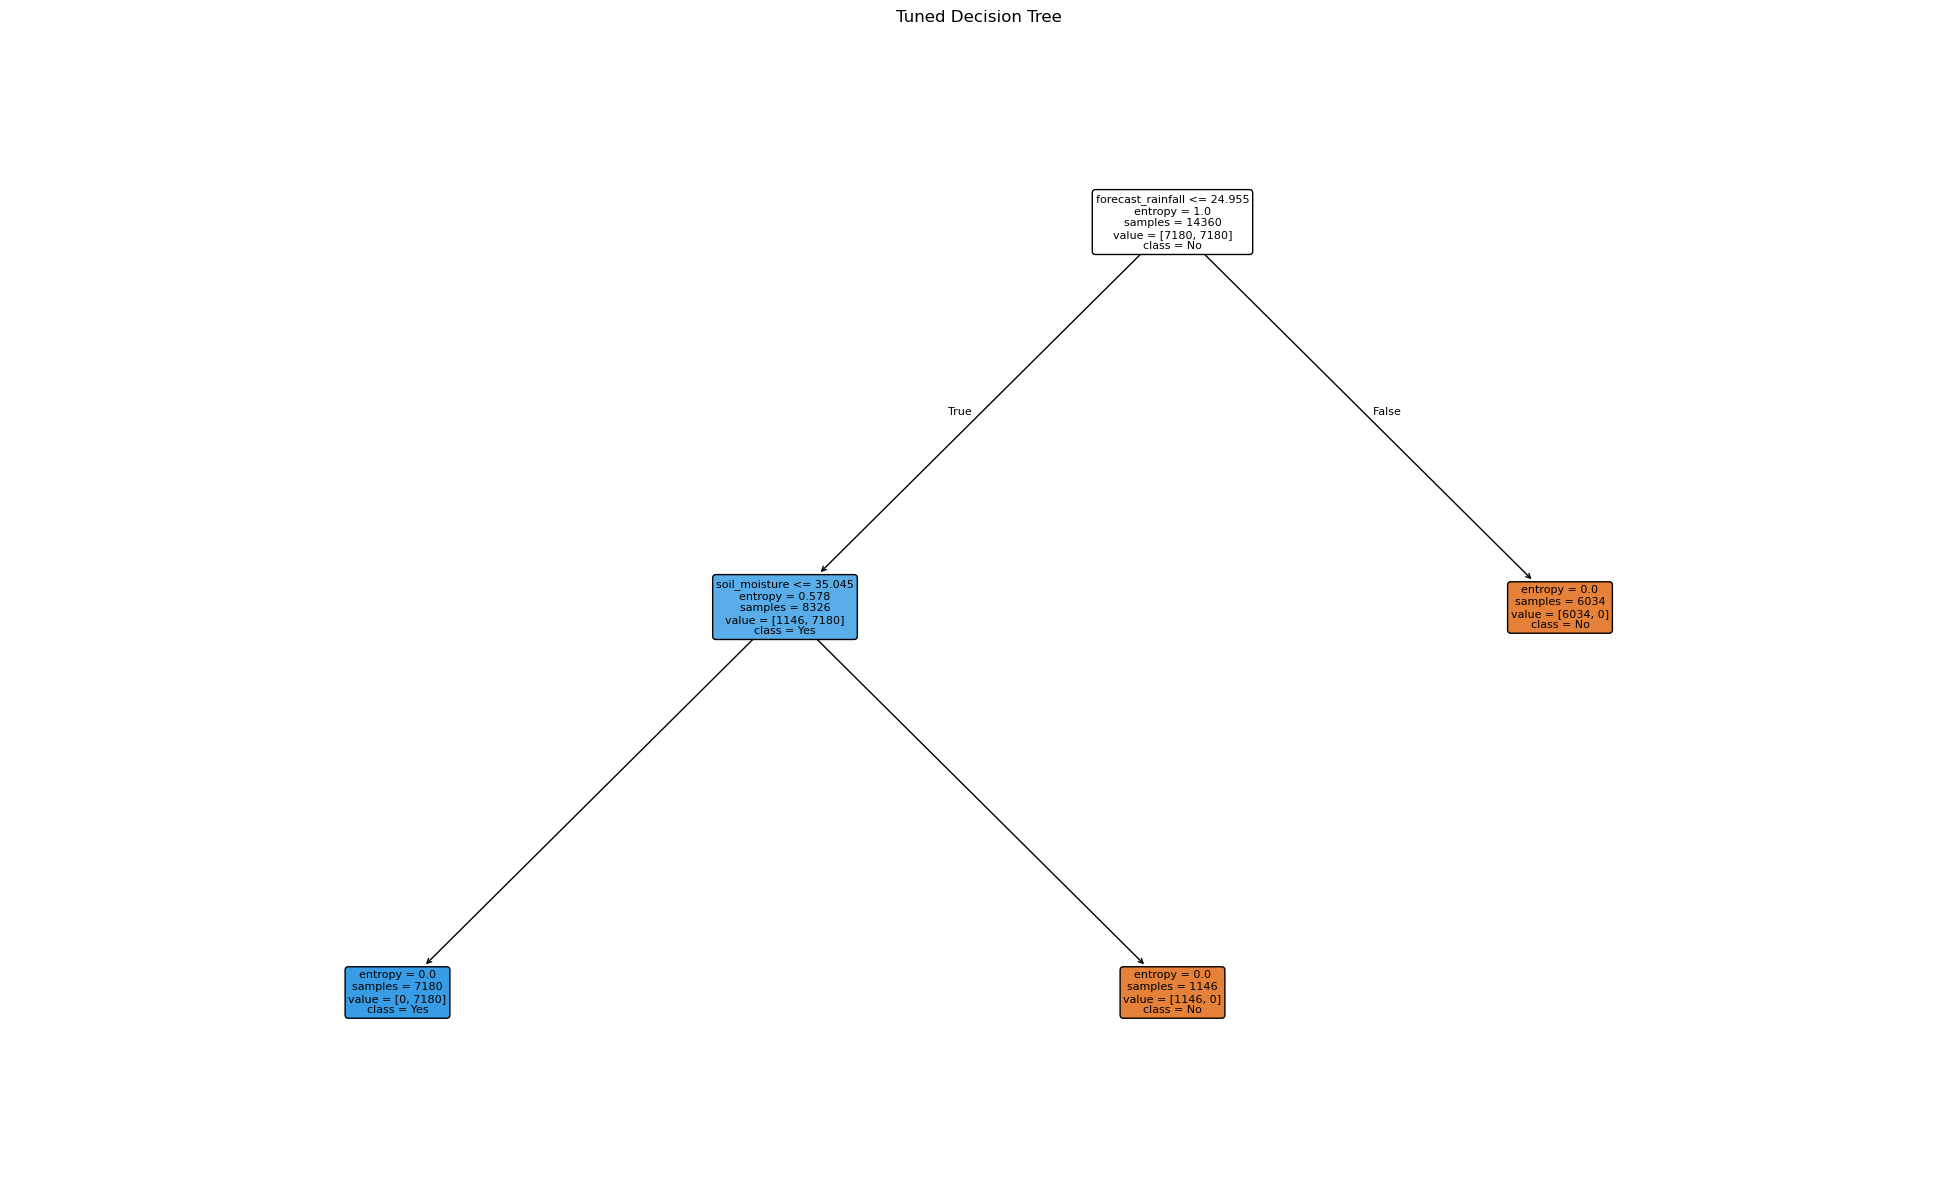

In [64]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,15))

plot_tree(
    best_decision,
    feature_names=X_train.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('Tuned Decision Tree')
plt.show()

# Confusion Matrix Heatmap for Decision Tree Using Hyper-Parameter Tuning

Text(0.5, 1.0, 'Confusion Matrix - Tuned Decision Tree')

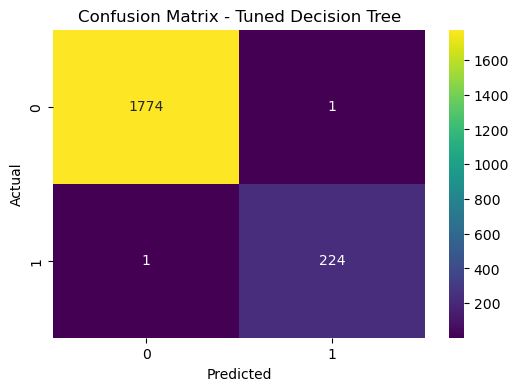

In [65]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_decision, annot=True, fmt='d', cmap='viridis')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Decision Tree")

# **ROC Curve For Decision Tree Using Hyper-Parameter Tuning**


ROC-AUC Score : 0.9975


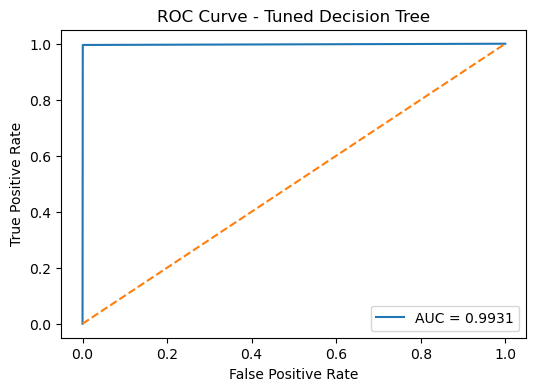

In [67]:
fpr, tpr, thresholds = roc_curve(y_test, y_probab_decision_tune)

auc_score_dt = roc_auc_score(y_test, y_probab_decision_tune)

print("ROC-AUC Score :", round(auc_score_dt, 4))

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Decision Tree")
plt.legend()

plt.show()

# **Comparison**

In [70]:
Comparison_dt = pd.DataFrame({
    'Metric' : [
        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Default_DT' : [
         accuracy_score(y_train,training_prediction),
         accuracy_score(y_test,testing_prediction),
         f1_score(y_test,testing_prediction),
         precision_score(y_test,testing_prediction),
         recall_score(y_test,testing_prediction),
         roc_auc_score(y_test, y_probab_decision)
    ],
    'Tuned DT' : [
        accuracy_score(y_train,training_prediction_dt),
        accuracy_score(y_test,testing_prediction_dt),
        precision_score(y_test,testing_prediction_dt),
        recall_score(y_test,testing_prediction_dt),
        grid_search_dt.best_score_,
        roc_auc_score(y_test, y_probab_decision_tune)

        
    ]
    
    
})

Comparison_dt.iloc[:,1:] = Comparison_dt.iloc[:,1:].round(3)

In [71]:
Comparison_dt


,Metric,Default_DT,Tuned DT
0,Train Accuracy,1.000,1.000
1,Test Accuracy,0.998,0.999
2,Precision,0.991,0.996
3,Recall,0.996,0.996
4,F1 Score,0.987,1.000
5,ROC-AUC,0.993,0.997


# **Feature Importance**

In [72]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_decision.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
4,forecast_rainfall,0.664857
10,soil_moisture,0.335143
0,growth_stage,0.000000
33,crop_type_Rice,0.000000
25,crop_health_index,0.000000
26,previous_yield,0.000000
27,groundwater_level,0.000000
28,reservoir_level,0.000000
29,fertilizer_usage,0.000000
30,labor_hours,0.000000


C:\Users\Sourabh\AppData\Local\Temp\ipykernel_20920\3018957300.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


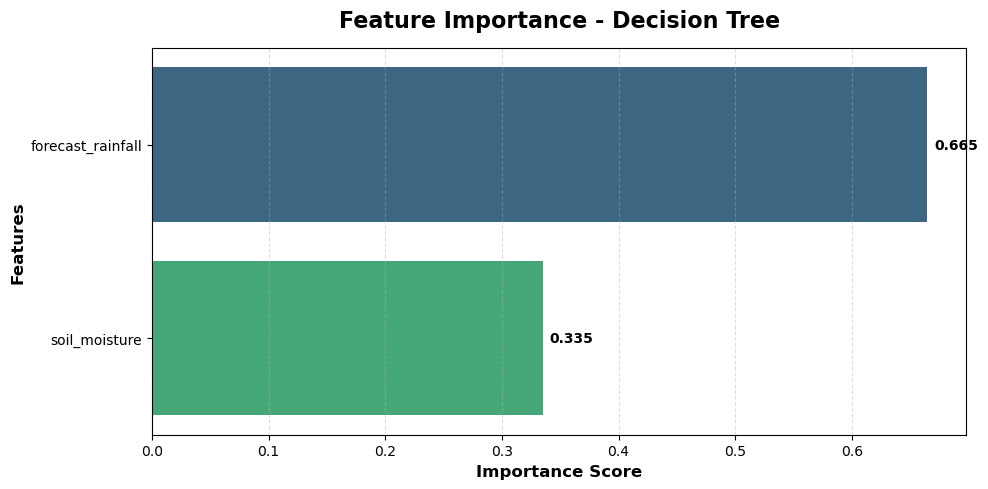

In [73]:
important_features = feature_importance[
    feature_importance['Importance'] > 0
]

# Style
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=important_features,
    x='Importance',
    y='Feature',
    palette='viridis'
)

# Title
plt.title(
    'Feature Importance - Decision Tree',
    fontsize=16,
    fontweight='bold',
    pad=15
)

# Axis Labels
plt.xlabel(
    'Importance Score',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Features',
    fontsize=12,
    fontweight='bold'
)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=5,
        fontsize=10,
        fontweight='bold'
    )

# Grid
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

# Improve layout
plt.tight_layout()

plt.show()

Interpritation:Feature importance analysis revealed that forecast rainfall (66.49%) and soil moisture (33.51%) were the most influential variables in predicting irrigation requirements. All other features contributed negligibly to the final decision tree. This finding aligns with agricultural domain knowledge, as irrigation decisions primarily depend on current soil moisture levels and expected rainfall conditions.

# **3.Random Forest**

In [74]:
df = pd.read_csv('D:\Machine Learning\Smart-Irrigation-Project\Data\processed\smart_irrigation_cleaned.csv')
df.head()

,growth_stage,temperature,humidity,rainfall,forecast_rainfall,wind_speed,solar_radiation,pressure,cloud_cover,dew_point,...,crop_type_Sugarcane,crop_type_Wheat,region_North,region_South,region_West,soil_type_Loamy,soil_type_Sandy,soil_type_Silty,irrigation_type_Flood,irrigation_type_Sprinkler
0,3,30.11,56.83,244.37,25.49,16.22,494.42,956.28,18.19,7.38,...,0,0,0,0,0,1,0,0,0,0
1,2,16.98,33.83,77.67,7.17,14.98,958.41,971.66,49.19,28.17,...,0,0,0,0,1,0,0,1,0,1
2,2,41.51,56.24,241.26,38.82,4.25,944.36,1022.92,2.19,16.81,...,1,0,1,0,0,0,0,0,0,1
3,3,37.59,34.14,124.00,73.21,3.65,712.11,976.40,35.25,23.10,...,0,0,0,0,0,0,0,0,0,0
4,2,26.36,72.79,79.94,21.39,3.91,995.69,970.73,5.53,22.34,...,0,0,0,0,0,0,1,0,0,0


In [75]:
from sklearn.ensemble import RandomForestClassifier

In [76]:
random = RandomForestClassifier()
random.fit(x_train_balanced,y_train_balanced)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
#check training and testing accuracy
training_predicttion_rf = random.predict(X_train)
testing_prediction_rf = random.predict(X_test)

In [80]:
y_probab_random = random.predict_proba(X_test) [:,1]

# **Check Accuracy**

In [81]:
training_accuracy_rf = accuracy_score(y_train,training_predicttion_rf)
testing_accuracy_rf = accuracy_score(y_test,testing_prediction_rf)

print("Training Accuracy Is:",round(training_accuracy_rf*100,2))
print("Testing Accuracy Is:",round(testing_accuracy_rf*100,2))

Training Accuracy Is: 100.0
Testing Accuracy Is: 99.8


In [82]:
Accuracy_gap_rf = training_accuracy_rf - testing_accuracy_rf

print("Accuracy gap Is:",round(Accuracy_gap_rf*100,2))

Accuracy gap Is: 0.2


In [86]:
print("                     Classification Report \n",classification_report(y_test,testing_prediction_rf))
print("F1 Score Is:",round(f1_score(y_test,testing_prediction_rf),4))
print("Precision Score Is:",round(precision_score(y_test,testing_prediction_rf),4))
print("Recall Score Is:",round(recall_score(y_test,testing_prediction_rf),4))
cm_random = confusion_matrix(y_test,testing_prediction_rf)


                     Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1775
           1       1.00      0.98      0.99       225

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

F1 Score Is: 0.991
Precision Score Is: 1.0
Recall Score Is: 0.9822


# **Confusion Matrix Heatmap for Random Forest**

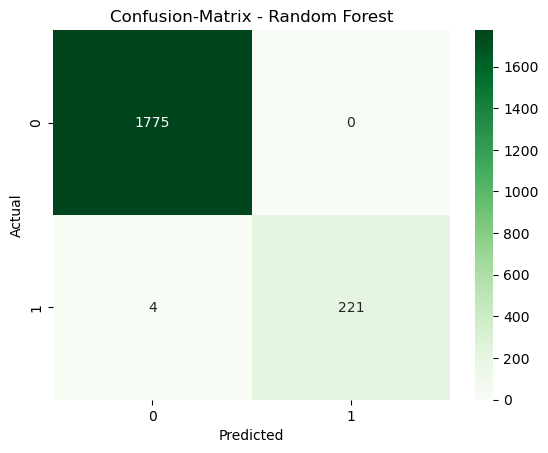

In [87]:
sns.heatmap(cm_random,annot=True, fmt='d', cmap='Greens')
plt.title("Confusion-Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **ROC Curve For Random Forest**

ROC-AUC Score : 1.0


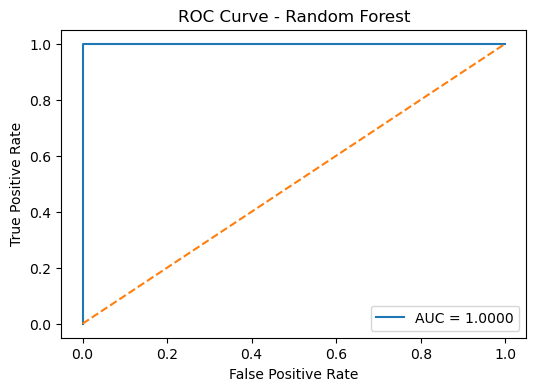

In [88]:
fpr, tpr, thresholds = roc_curve(y_test, y_probab_random)

auc_score = roc_auc_score(y_test, y_probab_random)

print("ROC-AUC Score :", round(auc_score, 4))

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

# **Random Forest Hyper-Parameter Tuning**

In [89]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],

    'max_depth': [10, 20, None],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4],

    'max_features': ['sqrt', 'log2'],

    'bootstrap': [True]
}

In [90]:
random_tune = RandomForestClassifier()

In [91]:
grid_rf = GridSearchCV(
    estimator= random_tune,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
    
    
)

In [92]:
grid_rf.fit(x_train_balanced,y_train_balanced)



Fitting 5 folds for each of 162 candidates, totalling 810 fits


,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [93]:
print("Best Parameters:",grid_rf.best_params_)

print("\nBest CV F1 Score:")
print(round(grid_rf.best_score_, 4))

Best Parameters: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best CV F1 Score:
0.9989


In [94]:
best_rf = grid_rf.best_estimator_

In [95]:
train_pred_rf = best_rf.predict(X_train)
test_pred_rf = best_rf.predict(X_test)

# Probabilities


y_prob_rf = best_rf.predict_proba(X_test)[:,1]

# **Accuracy Check**

In [96]:
from sklearn.metrics import accuracy_score

train_accuracy_rf = accuracy_score(y_train, train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, test_pred_rf)

print("Training Accuracy :", round(train_accuracy_rf*100,2))
print("Testing Accuracy  :", round(test_accuracy_rf*100,2))

accuracy_gap_rf = train_accuracy_rf - test_accuracy_rf

print("Accuracy Gap      :", round(accuracy_gap_rf*100,2))

Training Accuracy : 100.0
Testing Accuracy  : 99.75
Accuracy Gap      : 0.25


In [97]:
f1_score_rf = round(f1_score(y_test, test_pred_rf), 4)
precision_score_rf = round(precision_score(y_test, test_pred_rf), 4)
recall_rf = round(recall_score(y_test, test_pred_rf), 4)

In [98]:
print("classification_report \n", classification_report(y_test,test_pred_rf))
print("F1 Score Is:",round(f1_score(y_test,test_pred_rf),4))
print("Precision Score Is:",round(precision_score(y_test,test_pred_rf),4))
print("Recall Score Is:",round(recall_score(y_test,test_pred_rf),4))
cm_random_tune = confusion_matrix(y_test,test_pred_rf)

classification_report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1775
           1       1.00      0.98      0.99       225

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

F1 Score Is: 0.9888
Precision Score Is: 1.0
Recall Score Is: 0.9778


# **Confusion Matrix Heatmap for Random Forest Using Hyper-Parameter Tuning**

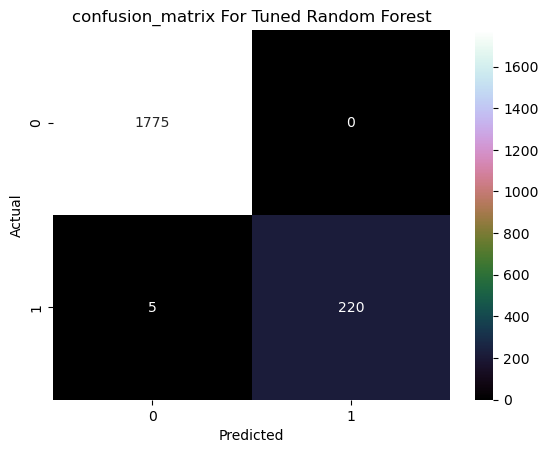

In [99]:
sns.heatmap(cm_random_tune,annot=True,fmt='d', cmap='cubehelix')
plt.title('confusion_matrix For Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **ROC Curve For Random Forest Using Hyper Parameter Tuning**

ROC-AUC Score : 1.0


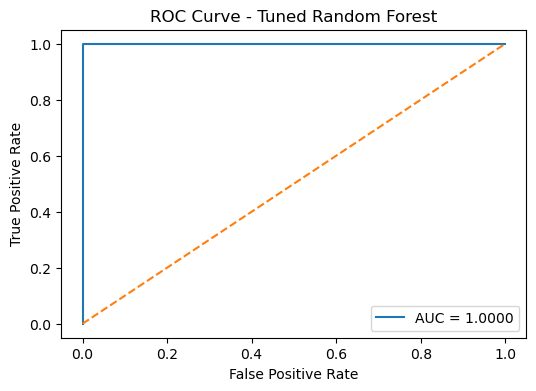

In [100]:
fpr, tpr, thresholds = roc_curve(y_test,y_prob_rf )

auc_score_rf = roc_auc_score(y_test,y_prob_rf)

print("ROC-AUC Score :", round(auc_score_rf, 4))

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()

plt.show()

# **Feature Importance**

In [101]:
feature_importance_rf = pd.DataFrame({
    'feature' : X_train.columns,
    'Importance' : best_rf.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features\n")
print(feature_importance_rf.head(10))


Top 10 Important Features

                      feature  Importance
4           forecast_rainfall    0.414836
10              soil_moisture    0.283695
31    crop_water_stress_level    0.044134
43  irrigation_type_Sprinkler    0.019744
32            crop_type_Maize    0.017983
39            soil_type_Loamy    0.017312
41            soil_type_Silty    0.015659
38                region_West    0.015342
42      irrigation_type_Flood    0.014997
33             crop_type_Rice    0.014986


C:\Users\Sourabh\AppData\Local\Temp\ipykernel_20920\2530288639.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


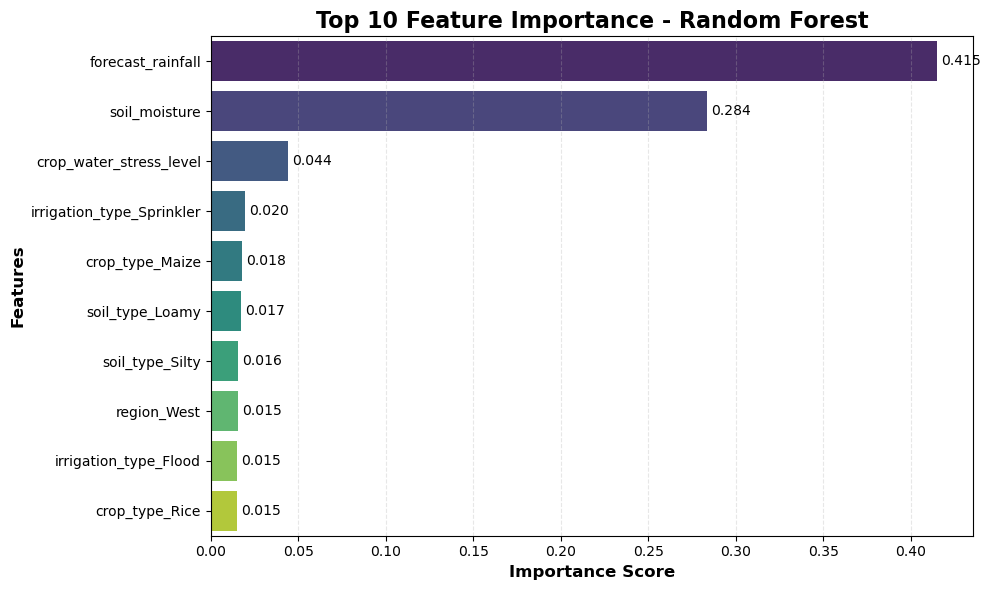

In [102]:
top_features_rf = feature_importance_rf.head(10)

plt.figure(figsize=(10,6))

# top_features_rf has column names 'feature' and 'Importance' (lowercase 'feature'),
# so use y='feature' to match the dataframe column name.
ax = sns.barplot(
    data=top_features_rf,
    x='Importance',
    y='feature',
    palette='viridis'
)

plt.title(
    'Top 10 Feature Importance - Random Forest',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Importance Score',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Features',
    fontsize=12,
    fontweight='bold'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

Random Forest feature importance suggests that future_soil_moisture_3day and water_quantity_required_liters may introduce target leakage and should be investigated in future experiments.

In [103]:
comparison_df = pd.DataFrame({
    'Metric': [
        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],

    'Logistic Regression': [
        train_accuracy_lr,
        test_accuracy_lr,
        precision_score_lr,
        recall_lr,
        f1_score_lr,
        auc_score_lr
    ],

    'Decision Tree': [
        training_accuracy_dt,
        testing_accuracy_dt,
        precision_score_dt,
        recall_dt,
        f1_score_dt,
        auc_score_dt

        
    ],

    'Random Forest': [
        training_accuracy_rf,
        testing_accuracy_rf,
        precision_score_rf,
        recall_rf,
        f1_score_rf,
        auc_score_rf
    ]
})

comparison_df

,Metric,Logistic Regression,Decision Tree,Random Forest
0,Train Accuracy,0.962625,1.000000,1.000000
1,Test Accuracy,0.962000,0.999000,0.998000
2,Precision,0.801600,0.995600,1.000000
3,Recall,0.880000,0.995600,0.977800
4,F1 Score,0.839000,0.995600,0.988800
5,ROC-AUC,0.989504,0.997496,0.999995


# **Conclusion**

Three classification models were evaluated for Irrigation Requirement Prediction: Logistic Regression, Decision Tree, and Random Forest. Random Forest was selected as the final model because it achieved excellent test accuracy (99.8%), perfect precision (100%), a high F1 score (98.88%), and the highest ROC-AUC score (0.999995). Compared to a single Decision Tree, Random Forest provides better robustness and generalization, making it more suitable for deployment in the Smart Irrigation System.


# **Save Model**

In [104]:
import joblib

joblib.dump(best_rf,
            '../models/irrigation_required_model.pkl')

['../models/irrigation_required_model.pkl']

In [105]:
import joblib

# Save feature names
joblib.dump(
    X.columns.tolist(),
    "../models/irrigation_features.pkl"
)

print("Irrigation features saved successfully")

Irrigation features saved successfully


In [106]:
features = joblib.load(
    "../models/irrigation_features.pkl"
)

print(features)
print("Total Features:", len(features))

['growth_stage', 'temperature', 'humidity', 'rainfall', 'forecast_rainfall', 'wind_speed', 'solar_radiation', 'pressure', 'cloud_cover', 'dew_point', 'soil_moisture', 'soil_temperature', 'soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'organic_matter', 'ec', 'leaf_wetness', 'evapotranspiration', 'ndvi', 'crop_age_days', 'water_usage', 'pest_risk', 'disease_risk', 'crop_health_index', 'previous_yield', 'groundwater_level', 'reservoir_level', 'fertilizer_usage', 'labor_hours', 'crop_water_stress_level', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Sugarcane', 'crop_type_Wheat', 'region_North', 'region_South', 'region_West', 'soil_type_Loamy', 'soil_type_Sandy', 'soil_type_Silty', 'irrigation_type_Flood', 'irrigation_type_Sprinkler']
Total Features: 44
